In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Files Extracted Successfully")

Files Extracted Successfully


In [4]:
df = pd.read_csv('ai_company_adoption.csv')

df.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [5]:
df.shape

(150000, 43)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  object 
 13 

In [7]:
df.columns

Index(['response_id', 'company_id', 'survey_year', 'quarter', 'country',
       'region', 'industry', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
       'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction',
       'survey_source', 'data_collection_meth

In [8]:
df.isnull().sum()

,0
response_id,0
company_id,0
survey_year,0
quarter,0
country,0
region,0
industry,0
company_size,0
num_employees,0
annual_revenue_usd_millions,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['company_id'].nunique()

10000

In [12]:
df['ai_primary_tool'].value_counts()

,count
ai_primary_tool,
ChatGPT,46103
Claude,24562
Custom Internal AI,24300
Gemini,23996
GitHub Copilot,20377
Other,10662


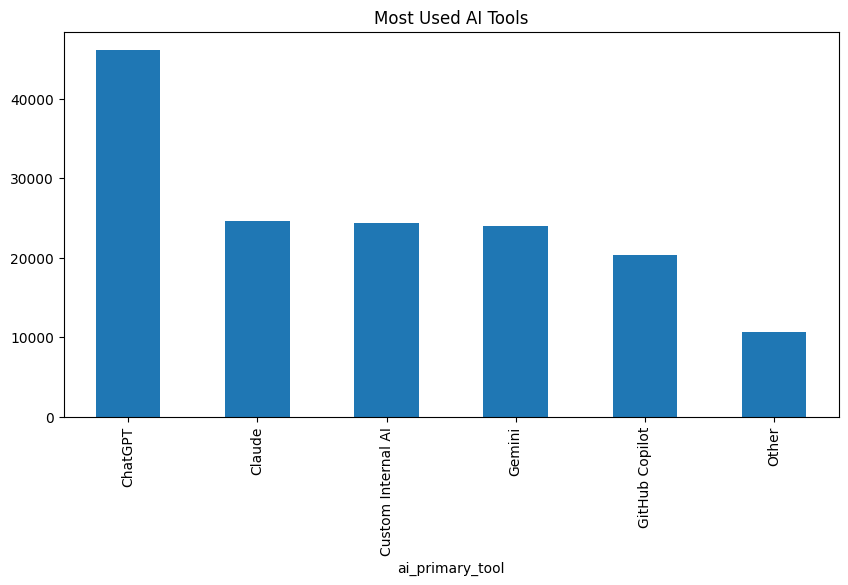

In [13]:
plt.figure(figsize=(10,5))

df['ai_primary_tool'].value_counts().plot(kind='bar')

plt.title("Most Used AI Tools")
plt.show()

In [14]:
df['industry'].value_counts()

,count
industry,
Technology,21107
Finance,20166
Healthcare,18642
Manufacturing,17501
Retail,16377
Agriculture,15570
Education,15172
Logistics,12961
Consulting,12504


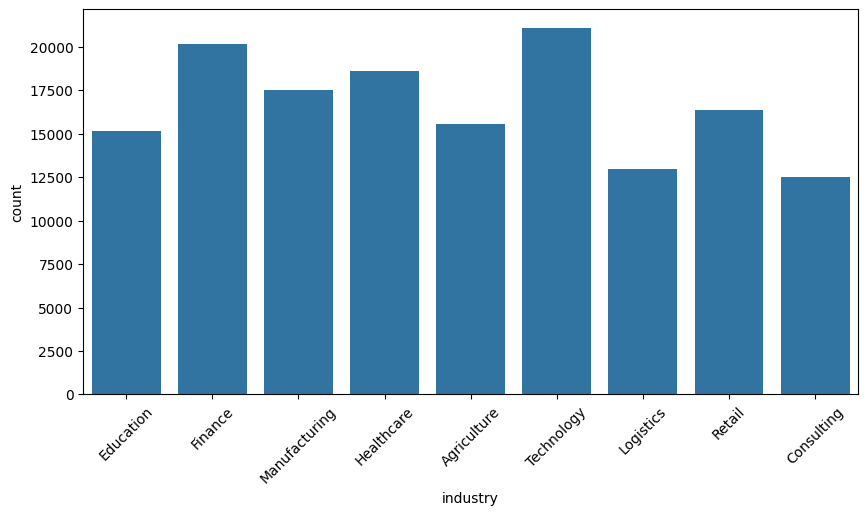

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='industry'
)

plt.xticks(rotation=45)

plt.show()

In [16]:
df['productivity_change_percent'].mean()

np.float64(9.266995933333334)

In [17]:
df['productivity_change_percent'].median()

9.06

In [18]:
df['productivity_change_percent'].quantile(
    [0.25,0.50,0.75]
)

,productivity_change_percent
0.25,5.07
0.50,9.06
0.75,13.12


In [19]:
df['productivity_change_percent'].std()

5.637066789480594

In [20]:
df['productivity_change_percent'].quantile(
    [0.10,0.90]
)

,productivity_change_percent
0.1,1.56
0.9,16.78


In [21]:
df.groupby('industry')[
    'ai_adoption_rate'
].mean()

,ai_adoption_rate
industry,
Agriculture,35.251479
Consulting,34.516004
Education,35.225152
Finance,38.348494
Healthcare,34.570853
Logistics,35.262117
Manufacturing,34.727883
Retail,34.699815
Technology,42.470735


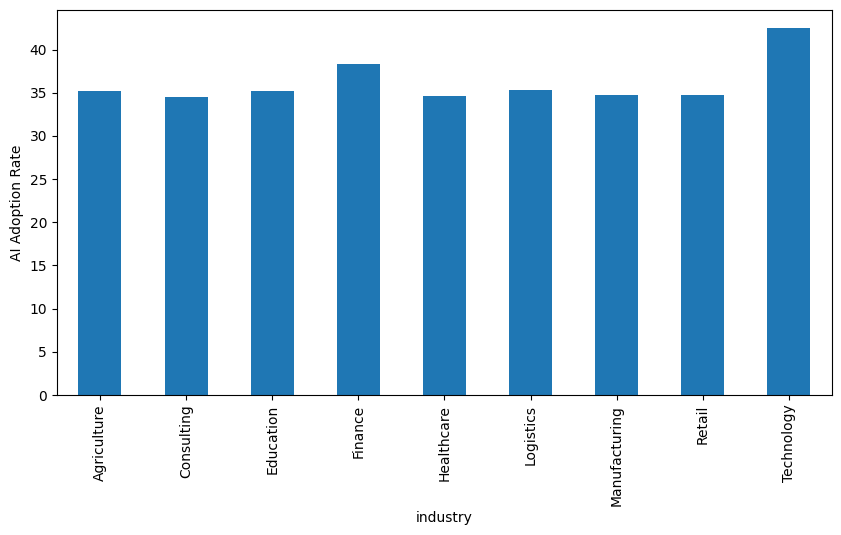

In [22]:
industry_avg = df.groupby(
    'industry'
)['ai_adoption_rate'].mean()

industry_avg.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel("AI Adoption Rate")
plt.show()

In [23]:
df['company_size'].value_counts()

,count
company_size,
SME,63867
Startup,56685
Enterprise,29448


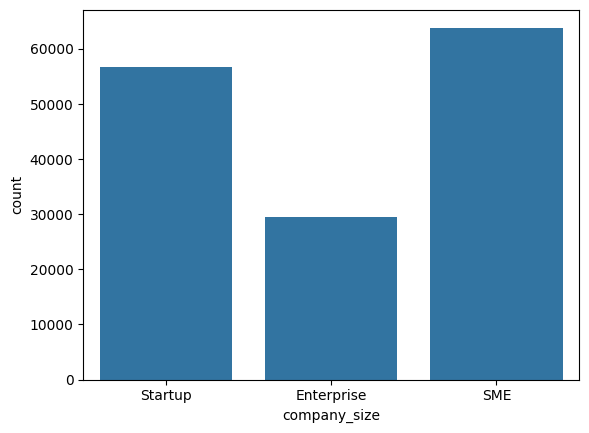

In [24]:
sns.countplot(
    data=df,
    x='company_size'
)

plt.show()

In [25]:
industry_adoption = df.groupby(
    'industry'
)['ai_adoption_rate'].mean()

industry_adoption.sort_values(
    ascending=False
)

,ai_adoption_rate
industry,
Technology,42.470735
Finance,38.348494
Logistics,35.262117
Agriculture,35.251479
Education,35.225152
Manufacturing,34.727883
Retail,34.699815
Healthcare,34.570853
Consulting,34.516004


In [26]:
size_adoption = df.groupby(
    'company_size'
)['ai_adoption_rate'].mean()

size_adoption

,ai_adoption_rate
company_size,
Enterprise,42.832443
SME,34.801376
Startup,34.898467


In [27]:
tool_satisfaction = df.groupby(
    'ai_primary_tool'
)['employee_satisfaction_score'].mean()

tool_satisfaction

,employee_satisfaction_score
ai_primary_tool,
ChatGPT,5.597573
Claude,5.604139
Custom Internal AI,5.601525
Gemini,5.599718
GitHub Copilot,5.612232
Other,5.585524


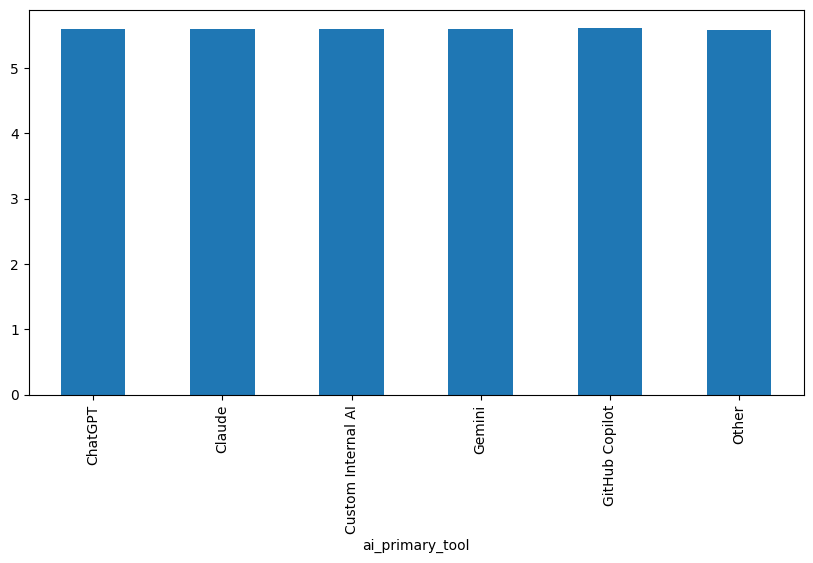

In [28]:
tool_satisfaction.plot(
    kind='bar',
    figsize=(10,5)
)

plt.show()

In [29]:
year_growth = df.groupby(
    'survey_year'
).size()

year_growth

,0
survey_year,
2023,37456
2024,37480
2025,37524
2026,37540


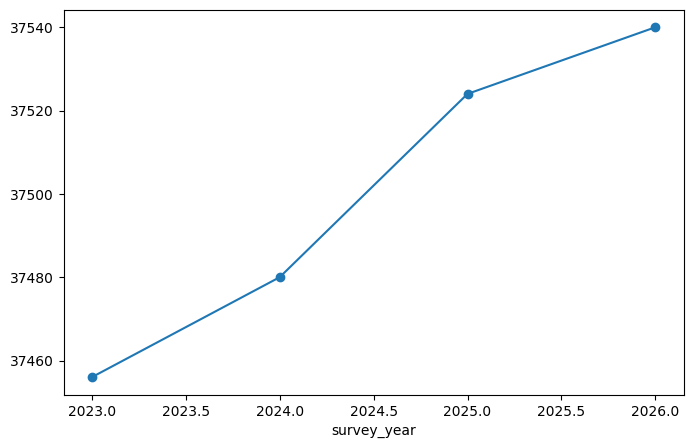

In [30]:
year_growth.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.show()

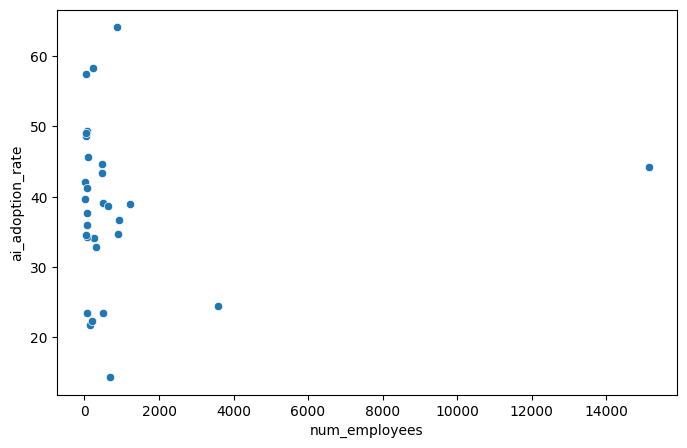

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(30),
    x='num_employees',
    y='ai_adoption_rate'
)

plt.show()

In [32]:
numeric_df = df.select_dtypes(
    include='number'
)

In [33]:
corr = numeric_df.corr()

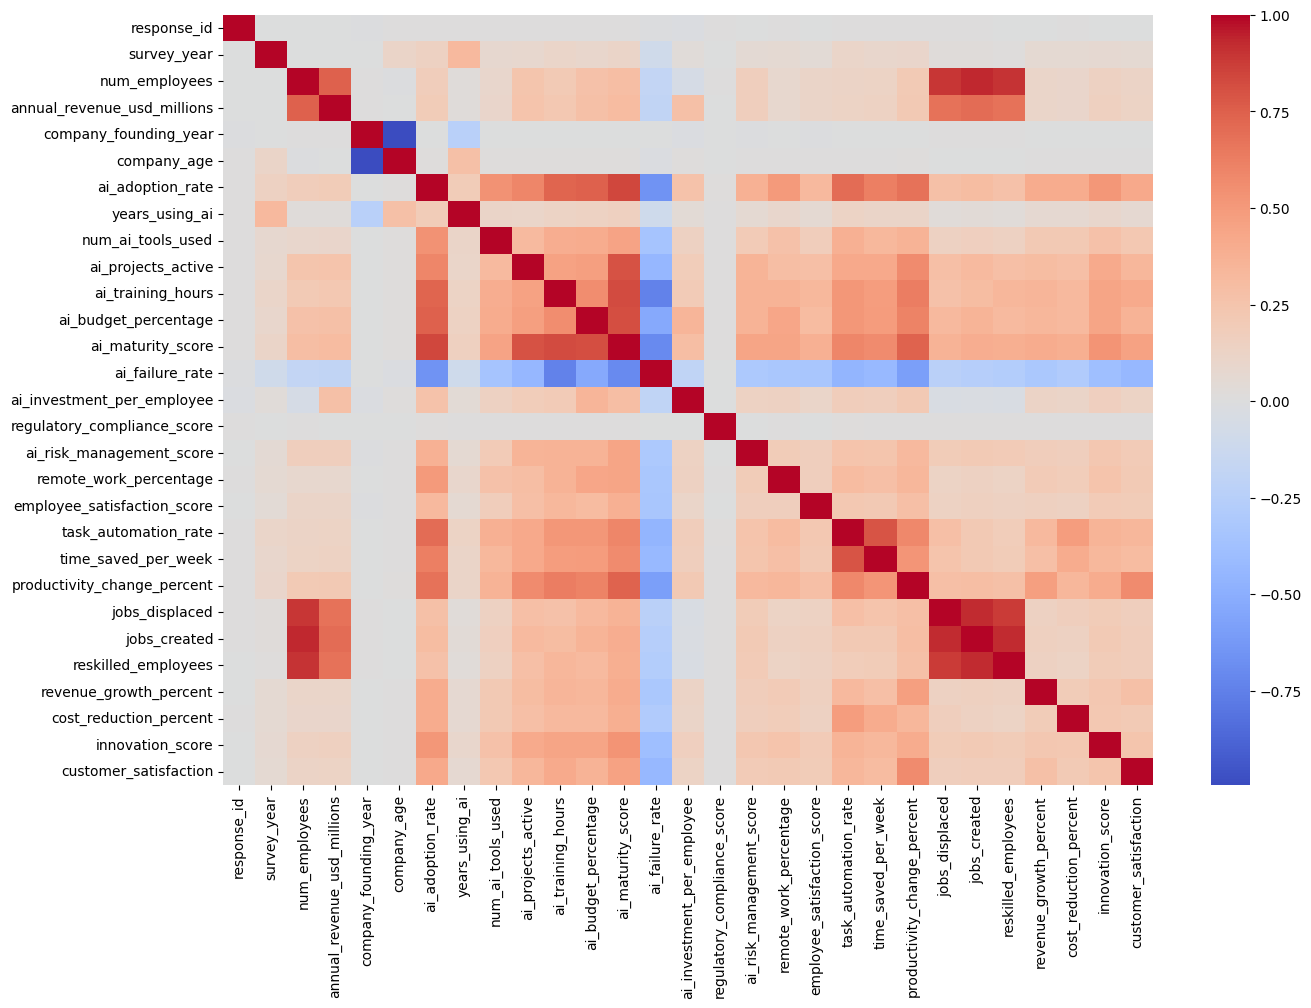

In [34]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

In [35]:
corr['productivity_change_percent'].sort_values(
    ascending=False
)

,productivity_change_percent
productivity_change_percent,1.000000
ai_maturity_score,0.737314
ai_adoption_rate,0.674973
ai_training_hours,0.633740
ai_budget_percentage,0.604105
task_automation_rate,0.582721
customer_satisfaction,0.569821
ai_projects_active,0.566833
time_saved_per_week,0.522476
revenue_growth_percent,0.476247


In [36]:
from scipy.stats import f_oneway

In [37]:
small = df[df['company_size']=='Small']['ai_adoption_rate']

medium = df[df['company_size']=='Medium']['ai_adoption_rate']

large = df[df['company_size']=='Large']['ai_adoption_rate']

f_stat,p_value = f_oneway(
    small,
    medium,
    large
)

print("P Value =",p_value)

P Value = nan


/tmp/ipykernel_3414/1137612742.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat,p_value = f_oneway(


In [38]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [39]:
leaders = df[
    (df['ai_adoption_rate'] > 80)
    &
    (df['productivity_change_percent'] > 20)
]

leaders.shape

(118, 43)

In [40]:
early = df[
    df['years_using_ai'] > 8
]

early.shape

(12053, 43)

In [41]:
high_sat = df[
    df['employee_satisfaction_score'] > 8
]

high_sat.shape

(249, 43)